# Notebook 3 — Ensembles Adaptativos, Métricas e Comparação

## Aula 3: Estratégias de Mitigação de Drift

### Objetivos
- Implementar **ADWINBoostingClassifier** (ensemble adaptativo com River)
- Calcular o **limiar ótimo sensível a custo** para churn telecom
- Comparar todas estratégias de mitigação: baseline, re-treinamento, online e ensemble
- Gerar relatório de avaliação e visualizações finais

### Teoria-Chave (Documento 04)

> "Em vez de concentrar toda a responsabilidade preditiva em um único modelo,  
> o sistema combina vários aprendizes, frequentemente treinados em tempos,  
> janelas ou regimes distintos. A vantagem está na redundância."  
> — Krawczyk et al. (2017)

### Vídeo Relacionado
- **Vídeo 4** — Ensembles Adaptativos para Absorver Drift (18 min)

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.model import AdaptiveEnsembleModel, BatchChurnModel, OnlineChurnModel
from src.training import (
    train_model, train_online, train_adaptive_ensemble, df_to_stream,
)
from src.evaluation import (
    calculate_metrics,
    optimal_cost_sensitive_threshold,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_drift_impact_timeline,
    compare_strategies_over_time,
    generate_evaluation_report,
)
from src.utils import load_model, save_metrics, ensure_dirs

sns.set_theme(style="whitegrid")
%matplotlib inline

ensure_dirs()

## 1. Preparação dos Dados

In [2]:
# Carrega e prepara dados
preprocessor = DataPreprocessor(seed=42)
data_path = Path.cwd().parent / "data" / "raw" / "dataset.csv"

if data_path.exists():
    df = preprocessor.load_data(str(data_path))
else:
    df = preprocessor.generate_and_save()

df = preprocessor.clean_data(df)
periods = preprocessor.split_by_period(df)

feature_cols = [
    "tenure_months", "monthly_charges", "total_charges",
    "data_usage_gb", "call_duration_min", "num_complaints",
    "payment_delay_days", "contract_type", "has_premium_support",
    "competitor_offer_exposure", "customer_value_segment",
]

# Preparar features por período
X_p1, y_p1 = preprocessor.prepare_features(periods[1])
X_p2, y_p2 = preprocessor.prepare_features(periods[2])
X_p3, y_p3 = preprocessor.prepare_features(periods[3])

print("Dados preparados.")

Dados preparados.


## 2. Ensemble Adaptativo — ADWINBoostingClassifier

Implementa o conceito do **Snippet 3** da seção *Hands On*:
```python
from river import ensemble, linear_model, preprocessing
model = ensemble.ADWINBoostingClassifier(
    model=preprocessing.StandardScaler() | linear_model.LogisticRegression(),
    n_models=5, seed=42,
)
```

> "A mitigação pode ser incorporada à própria arquitetura do modelo,  
> e não apenas adicionada como um remendo posterior."  
> — Documento 04, Seção Hands On

In [3]:
# Treina ensemble adaptativo
df_sorted = df.sort_values("timestamp_month").reset_index(drop=True)
stream = df_to_stream(df_sorted, feature_cols)

ensemble_model = train_adaptive_ensemble(stream, n_models=5, seed=42)

print(f"Amostras processadas: {ensemble_model.n_samples_seen}")
print(f"Acurácia acumulada: {ensemble_model.accuracy:.4f}")

Amostras processadas: 9000
Acurácia acumulada: 0.7991


## 3. Comparação: Acurácia por Janela — Online vs Ensemble

Conforme discutido no Vídeo 4: comparamos como cada estratégia  
responde ao drift ao longo do tempo.

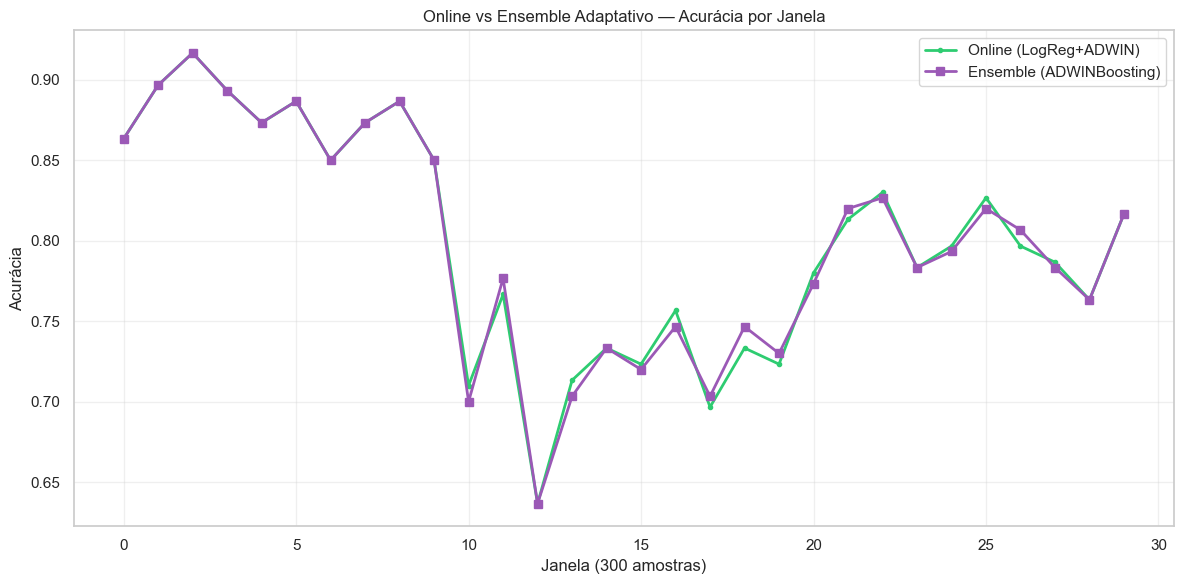

In [4]:
# Comparar online simples vs ensemble por janelas temporais
window_size = 300
online_m = OnlineChurnModel(seed=42)
ensemble_m = AdaptiveEnsembleModel(n_models=5, seed=42)

online_accs = []
ensemble_accs = []
correct_online, correct_ensemble = 0, 0
total_w = 0

for i, (x, y) in enumerate(stream):
    # Online
    pred_o = online_m.predict_one(x)
    if pred_o is not None:
        correct_online += int(pred_o == y)
    online_m.learn_one(x, y)

    # Ensemble
    pred_e = ensemble_m.predict_one(x)
    if pred_e is not None:
        correct_ensemble += int(pred_e == y)
    ensemble_m.learn_one(x, y)

    total_w += 1
    if (i + 1) % window_size == 0:
        online_accs.append(correct_online / total_w if total_w else 0)
        ensemble_accs.append(correct_ensemble / total_w if total_w else 0)
        correct_online, correct_ensemble, total_w = 0, 0, 0

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(online_accs)), online_accs, marker=".", label="Online (LogReg+ADWIN)",
        linewidth=2, color="#2ecc71")
ax.plot(range(len(ensemble_accs)), ensemble_accs, marker="s", label="Ensemble (ADWINBoosting)",
        linewidth=2, color="#9b59b6")
ax.set_xlabel(f"Janela ({window_size} amostras)")
ax.set_ylabel("Acurácia")
ax.set_title("Online vs Ensemble Adaptativo — Acurácia por Janela")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/online_vs_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Limiar Ótimo Sensível a Custo

Implementa a fórmula da seção *Saiba Mais*:

$$t^{\star} = \arg\min_t \left[C_{FN}\,\pi\,\bigl(1-\mathrm{TPR}(t)\bigr) + C_{FP}\,\bigl(1-\pi\bigr)\,\mathrm{FPR}(t)\right]$$

> "Se o custo de perder um cliente valioso for substancialmente maior  
> do que o custo de contatar um cliente que ficaria, reduzir o limiar  
> pode ser racional."  
> — Fawcett (2006); Provost & Fawcett (2013)

In [5]:
# Treina baseline e obtém probabilidades no P3
baseline = train_model(X_p1, y_p1, model_type="logistic")
y_proba_p3 = baseline.predict_proba(X_p3)[:, 1]

# Análise com duas configurações de custo
cost_default = optimal_cost_sensitive_threshold(
    y_p3.values, y_proba_p3, cost_fn=1.0, cost_fp=1.0
)
cost_churn = optimal_cost_sensitive_threshold(
    y_p3.values, y_proba_p3, cost_fn=10.0, cost_fp=1.0
)

print("Limiar ótimo (custo simétrico C_FN=1, C_FP=1):")
print(f"  Threshold: {cost_default['optimal_threshold']:.4f}")
print(f"  TPR: {cost_default['tpr_at_optimal']:.4f}")
print(f"  FPR: {cost_default['fpr_at_optimal']:.4f}")

print(f"\nLimiar ótimo (custo assimétrico C_FN=10, C_FP=1):")
print(f"  Threshold: {cost_churn['optimal_threshold']:.4f}")
print(f"  TPR: {cost_churn['tpr_at_optimal']:.4f}")
print(f"  FPR: {cost_churn['fpr_at_optimal']:.4f}")

Limiar ótimo (custo simétrico C_FN=1, C_FP=1):
  Threshold: 0.3807
  TPR: 0.0068
  FPR: 0.0004

Limiar ótimo (custo assimétrico C_FN=10, C_FP=1):
  Threshold: 0.0481
  TPR: 0.9898
  FPR: 0.9137


## 5. Curva ROC e Confusion Matrix

Conforme Fawcett (2006): a curva ROC é fundamental para avaliar  
degradação sob drift e escolher o ponto operacional adequado.

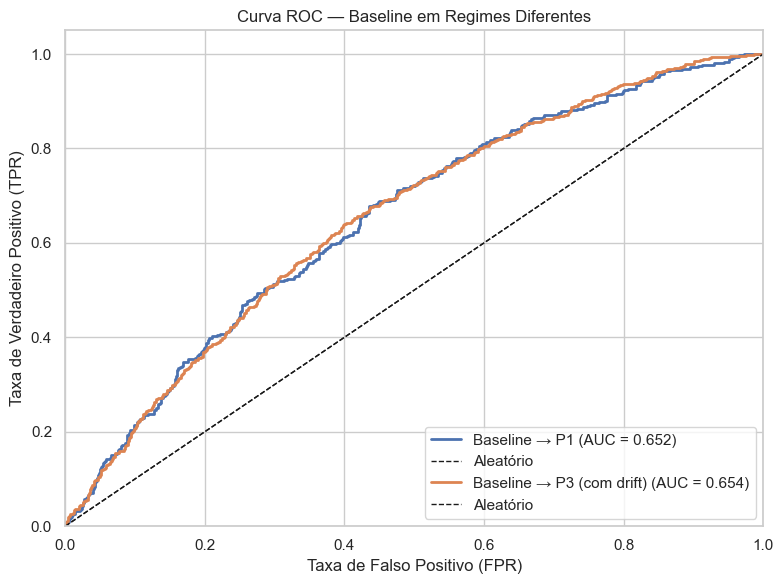

In [6]:
# Curva ROC — Baseline no P1 vs P3
y_proba_p1 = baseline.predict_proba(X_p1)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_curve(y_p1.values, y_proba_p1, label="Baseline → P1", ax=ax)
plot_roc_curve(y_p3.values, y_proba_p3, label="Baseline → P3 (com drift)", ax=ax)
ax.set_title("Curva ROC — Baseline em Regimes Diferentes")
plt.savefig("../outputs/figures/roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

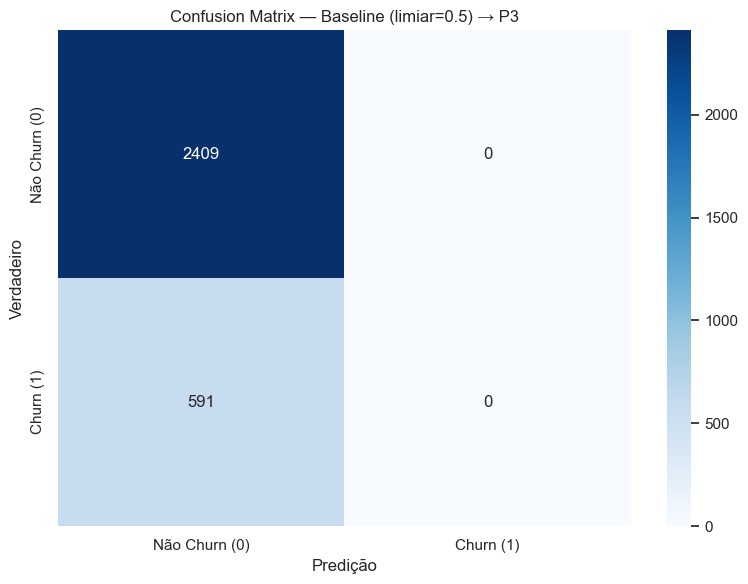

In [7]:
# Confusion Matrix — Baseline no P3 com limiar padrão (0.5)
y_pred_default = (y_proba_p3 >= 0.5).astype(int)
fig = plot_confusion_matrix(
    y_p3.values, y_pred_default,
    title="Confusion Matrix — Baseline (limiar=0.5) → P3",
    save_path="../outputs/figures/cm_baseline_p3.png"
)
plt.show()

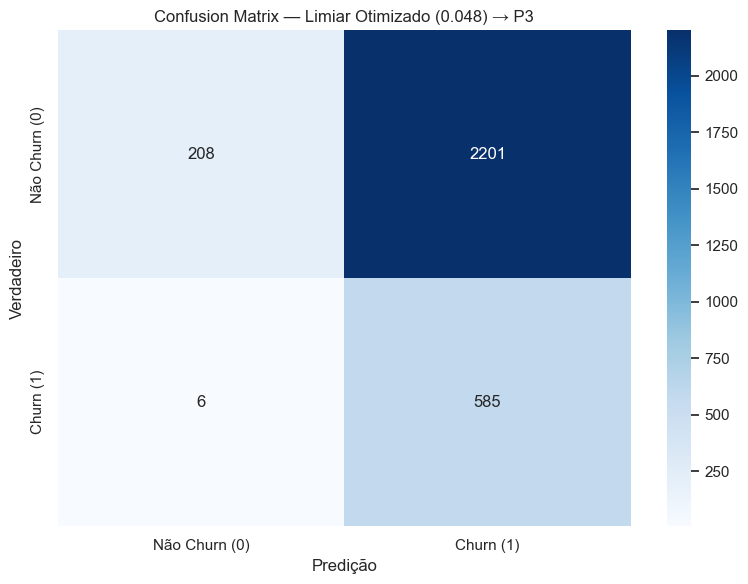

Métricas com limiar 0.5:
{'accuracy': 0.803, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'auc_roc': 0.6543271530407335}

Métricas com limiar otimizado (0.048):
{'accuracy': 0.2643333333333333, 'f1': 0.34646135623334323, 'precision': 0.20997846374730797, 'recall': 0.9898477157360406, 'auc_roc': 0.6543271530407335}


In [8]:
# Confusion Matrix com limiar otimizado para custo
y_pred_optimized = (y_proba_p3 >= cost_churn["optimal_threshold"]).astype(int)
fig = plot_confusion_matrix(
    y_p3.values, y_pred_optimized,
    title=f"Confusion Matrix — Limiar Otimizado ({cost_churn['optimal_threshold']:.3f}) → P3",
    save_path="../outputs/figures/cm_optimized_p3.png"
)
plt.show()

# Comparar métricas
print("Métricas com limiar 0.5:")
print(calculate_metrics(y_p3.values, y_pred_default, y_proba_p3))
print(f"\nMétricas com limiar otimizado ({cost_churn['optimal_threshold']:.3f}):")
print(calculate_metrics(y_p3.values, y_pred_optimized, y_proba_p3))

## 6. Comparação Final de Estratégias

Conforme **Tabela 1** do documento acadêmico e o encerramento do Vídeo 4:  
comparamos todas as estratégias implementadas.

> "O profissional maduro não pergunta apenas 'qual algoritmo usar?',  
> mas 'em que sequência de alavancas este sistema deve operar  
> quando a realidade mudar?'"  
> — Documento 04, Seção Saiba Mais

In [9]:
# Comparação: Baseline vs Re-treinado vs Limiar Otimizado
# Re-treinamento no P2 (dados mais recentes)
retrained = train_model(X_p2, y_p2, model_type="logistic")
y_pred_retrained = retrained.predict(X_p3)
y_proba_retrained = retrained.predict_proba(X_p3)[:, 1]

strategies_metrics = {
    "Baseline (P1)": calculate_metrics(y_p3.values, y_pred_default, y_proba_p3),
    "Re-treinado (P2)": calculate_metrics(y_p3.values, y_pred_retrained, y_proba_retrained),
    "Baseline + Limiar": calculate_metrics(y_p3.values, y_pred_optimized, y_proba_p3),
}

# Tabela comparativa
comparison_df = pd.DataFrame(strategies_metrics).T
comparison_df.round(4)

,accuracy,f1,precision,recall,auc_roc
Baseline (P1),0.8030,0.0000,0.0000,0.0000,0.6543
Re-treinado (P2),0.7863,0.2057,0.3843,0.1404,0.6719
Baseline + Limiar,0.2643,0.3465,0.2100,0.9898,0.6543


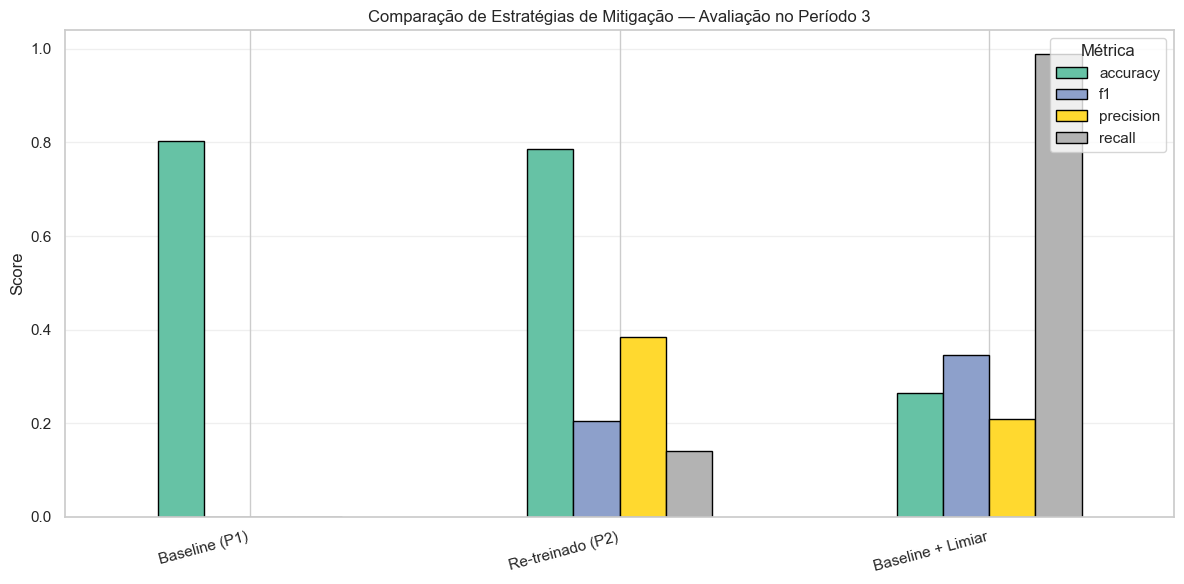

In [10]:
# Visualização radar/barras das estratégias
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df[["accuracy", "f1", "precision", "recall"]].plot(
    kind="bar", ax=ax, colormap="Set2", edgecolor="black",
)
ax.set_ylabel("Score")
ax.set_title("Comparação de Estratégias de Mitigação — Avaliação no Período 3")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(title="Métrica")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/figures/strategies_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Relatório de Avaliação

Conforme **Snippet 2** da seção *Hands On*: antes de decidir a intervenção,  
a equipe precisa de um relatório acionável.

In [11]:
# Relatório textual
report = generate_evaluation_report(
    strategies_metrics,
    cost_analysis=cost_churn,
)
print(report)

RELATÓRIO DE AVALIAÇÃO — ESTRATÉGIAS DE MITIGAÇÃO DE DRIFT

--- Baseline (P1) ---
      accuracy: 0.8030
            f1: 0.0000
     precision: 0.0000
        recall: 0.0000
       auc_roc: 0.6543

--- Re-treinado (P2) ---
      accuracy: 0.7863
            f1: 0.2057
     precision: 0.3843
        recall: 0.1404
       auc_roc: 0.6719

--- Baseline + Limiar ---
      accuracy: 0.2643
            f1: 0.3465
     precision: 0.2100
        recall: 0.9898
       auc_roc: 0.6543

--- Análise de Custo (Limiar Sensível a Custo) ---
  Limiar ótimo: 0.0481
  Custo mínimo: 0.7537
  TPR no ótimo: 0.9898
  FPR no ótimo: 0.9137
  C_FN / C_FP : 10.0 / 1.0



## 8. Camadas de Resposta ao Drift

Conforme discutido na seção *Saiba Mais* e no Vídeo 4:

| Camada | Ferramentas Implementadas |
|--------|-------------------------|
| **Observabilidade** | Monitoramento com Evidently (Snippet 2) |
| **Emergencial** | Ajuste de limiar sensível a custo |
| **Adaptativa** | Online learning (ADWIN) + Ensemble (ADWINBoosting) |
| **Estrutural** | Re-treinamento com janela deslizante + Champion/Challenger |

In [12]:
# Resumo final — salvar todas as métricas
final_report = {
    "strategies": {k: {m: round(v, 4) for m, v in metrics.items()}
                  for k, metrics in strategies_metrics.items()},
    "cost_analysis": {
        "symmetric": cost_default,
        "asymmetric_churn": cost_churn,
    },
    "online_model_accuracy": round(ensemble_model.accuracy, 4),
}
save_metrics(final_report, Path.cwd().parent / "outputs" / "logs" / "evaluation_report.json")
print("Relatório final salvo em outputs/logs/evaluation_report.json")

Relatório final salvo em outputs/logs/evaluation_report.json


## Resumo

Neste notebook finalizamos a implementação prática das estratégias de mitigação:

1. **Ensemble adaptativo (ADWINBoostingClassifier)** — absorve drift sem reiniciar
2. **Limiar ótimo sensível a custo** — ajusta política de decisão ao custo de erro
3. **Comparação quantitativa** entre baseline, re-treinamento e ajuste de limiar
4. **Relatório de avaliação** com métricas e análise de custo

### Mensagem Central

> "Mitigar drift é desenhar uma política de resposta proporcional  
> à velocidade da mudança e ao custo do erro, e não simplesmente  
> 'mandar treinar de novo' toda vez que as métricas balançarem."  
> — Lu et al. (2019); Krawczyk et al. (2017)

### Referências Implementadas
- Bifet & Gavaldà (2007) — ADWIN
- Fawcett (2006) — ROC e limiar sensível a custo
- Krawczyk et al. (2017) — Ensembles adaptativos
- Lu et al. (2019) — Framework de mitigação de concept drift
- Montiel et al. (2021) — River para streaming ML